# Convolutional Neural Network (CNN) for binary image classification.


## Assignment: Man vs Woman Image Classification




In [2]:
!unzip -qq men-women.zip

In [ ]:
# 1. Load the dataset (automatic labeling from subfolders)
train_ds = tf.keras.utils.image_dataset_from_directory('dataset/train', image_size=(150, 150), batch_size=32)
valid_ds = tf.keras.utils.image_dataset_from_directory('dataset/valid', image_size=(150, 150), batch_size=32)

## 1. Import Libraries

Run this cell first. If TensorFlow or another package is missing, install it in your environment before continuing.

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

## 2. Locate and Extract the ZIP Dataset

Upload the ZIP file to the same folder as this notebook.

The code below searches for ZIP files in the current working directory. If more than one ZIP file is found, select the correct one manually.

## 3. Find the Dataset Root Folder

This cell checks where the `train`, `valid`, `test`, and `predict` folders are located.

If your ZIP contains one extra parent folder, the code will detect it automatically.

In [5]:
import os
from pathlib import Path

# 1. Check current working directory
print("Current directory:", os.getcwd())

# 2. Check items in the current directory
print("Items in current directory:", os.listdir('.'))

# 3. Explicitly target the folder name directly
dataset_root = Path("men-women")

# Fallback: Search explicitly for any folder containing 'train'
if not dataset_root.exists():
    for p in Path('.').rglob('*'):
        if p.is_dir() and p.name.lower() in ['men-women', 'men_women', 'dataset']:
            dataset_root = p
            break

print("Resolved dataset_root:", dataset_root.resolve())

# 4. Set directory variables
TRAIN_DIR = dataset_root / "train"
VALID_DIR = dataset_root / "valid"
TEST_DIR = dataset_root / "test"
PREDICT_DIR = dataset_root / "predict"

# 5. Print contents of dataset_root to verify
if dataset_root.exists():
    print("\nContents of dataset_root:", [p.name for p in dataset_root.iterdir()])
else:
    print("\nERROR: Folder still not found! Check if you uploaded/extracted your dataset into Google Colab or Kaggle correctly.")

Current directory: /content
Items in current directory: ['.config', 'men-women', 'men-women.zip', 'sample_data']
Resolved dataset_root: /content/men-women

Contents of dataset_root: ['train', 'predict', 'val', 'test']


## Directory Paths

In [6]:
from pathlib import Path

# Set the dataset root to your verified location
dataset_root = Path("/content/men-women")

# Assign exact folder paths
TRAIN_DIR = dataset_root / "train"
VALID_DIR = dataset_root / "val"       # Fixed: named 'val' in your directory
TEST_DIR = dataset_root / "test"
PREDICT_DIR = dataset_root / "predict"

print("Dataset Root:", dataset_root)
print("Train Path:  ", TRAIN_DIR)
print("Valid Path:  ", VALID_DIR)
print("Test Path:   ", TEST_DIR)
print("Predict Path:", PREDICT_DIR)

Dataset Root: /content/men-women
Train Path:   /content/men-women/train
Valid Path:   /content/men-women/val
Test Path:    /content/men-women/test
Predict Path: /content/men-women/predict


In [7]:
from pathlib import Path

# Paths setup
dataset_root = Path("/content/men-women")
TRAIN_DIR = dataset_root / "train"
VALID_DIR = dataset_root / "val"
TEST_DIR = dataset_root / "test"
PREDICT_DIR = dataset_root / "predict"

# 1. Count labeled splits (train, val, test)
print(f"{'SPLIT':<12} | {'MAN':<8} | {'WOMAN':<8} | {'TOTAL':<8}")
print("-" * 42)

total_dataset_images = 0

for split_name, folder_path in [("Train", TRAIN_DIR), ("Valid (val)", VALID_DIR), ("Test", TEST_DIR)]:
    man_path = folder_path / "man"
    woman_path = folder_path / "woman"

    # Get image counts for each subfolder
    man_count = len([f for f in man_path.glob("*") if f.is_file()]) if man_path.exists() else 0
    woman_count = len([f for f in woman_path.glob("*") if f.is_file()]) if woman_path.exists() else 0
    split_total = man_count + woman_count

    total_dataset_images += split_total
    print(f"{split_name:<12} | {man_count:<8} | {woman_count:<8} | {split_total:<8}")

print("-" * 42)

# 2. Count unlabelled predict folder
predict_count = len([f for f in PREDICT_DIR.glob("*") if f.is_file()]) if PREDICT_DIR.exists() else 0
print(f"{'Predict':<12} | {'-':<8} | {'-':<8} | {predict_count:<8}")

print("=" * 42)
print(f"Grand Total Images: {total_dataset_images + predict_count}")

SPLIT        | MAN      | WOMAN    | TOTAL   
------------------------------------------
Train        | 400      | 400      | 800     
Valid (val)  | 200      | 200      | 400     
Test         | 200      | 200      | 400     
------------------------------------------
Predict      | -        | -        | 15      
Grand Total Images: 1615


## 4. Load the Datasets into Batches

In [8]:
import tensorflow as tf

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Load labeled datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

# Load unlabelled prediction dataset
predict_ds = tf.keras.utils.image_dataset_from_directory(
    PREDICT_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, labels=None, label_mode=None, shuffle=False
)

# Print detected class order (0 = man, 1 = woman)
class_names = train_ds.class_names
print(f"\nClass mapping: {class_names}")

Found 800 files belonging to 2 classes.
Found 400 files belonging to 2 classes.
Found 400 files belonging to 2 classes.
Found 15 files.

Class mapping: ['man', 'woman']


## Build the CNN Architecture

In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Rescale RGB pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(150, 150, 3)),

    # Convolutional & Pooling Layer Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Convolutional & Pooling Layer Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Convolutional & Pooling Layer Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Fully Connected Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(1, activation='sigmoid') # Sigmoid gives probability between 0 and 1
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train the Model

In [10]:
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam',  metrics=['accuracy'])

# Train model using train_ds and validate on valid_ds

history = model.fit( train_ds, epochs=10, validation_data=valid_ds )

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.5375 - loss: 0.7423 - val_accuracy: 0.6175 - val_loss: 0.6656
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5975 - loss: 0.6663 - val_accuracy: 0.6600 - val_loss: 0.6426
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6463 - loss: 0.6479 - val_accuracy: 0.5925 - val_loss: 0.6580
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.6550 - loss: 0.6201 - val_accuracy: 0.6775 - val_loss: 0.6203
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7100 - loss: 0.5589 - val_accuracy: 0.6600 - val_loss: 0.6263
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7900 - loss: 0.4854 - val_accuracy: 0.6750 - val_loss: 0.6258
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8100 - loss: 0.4093 - val_accuracy: 0.6800 - val_loss: 0.6993
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8487 - loss: 0.3588 - val_accuracy: 0.6675 - 

## Evaluate Model on Test Set

In [11]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.6900 - loss: 0.8911

Test Accuracy: 69.00%
Test Loss: 0.8911


## Predict on Unlabelled Mixed Folder
Run inference on the unlabelled images in predict/ and map predicted output values to "Man" or "Woman".

In [12]:
import numpy as np

# Get filename list in exact order loaded by predict_ds
file_paths = predict_ds.file_paths

# Run predictions
predictions = model.predict(predict_ds)

# Map raw probabilities to labels
print("\n--- Predictions for Unlabelled Images ---")
for file_path, pred in zip(file_paths, predictions):
    fname = Path(file_path).name
    prob = pred[0]

    # prob > 0.5 means Woman (Class 1), prob <= 0.5 means Man (Class 0)
    label = class_names[1] if prob > 0.5 else class_names[0]
    confidence = prob if prob > 0.5 else (1 - prob)

    print(f"File: {fname:<15} | Predicted: {label.upper():<5} | Confidence: {confidence * 100:.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

--- Predictions for Unlabelled Images ---
File: 0001.jpg        | Predicted: MAN   | Confidence: 95.5%
File: 0002.jpg        | Predicted: WOMAN | Confidence: 82.5%
File: 0003.jpg        | Predicted: WOMAN | Confidence: 86.1%
File: 0004.jpg        | Predicted: WOMAN | Confidence: 98.3%
File: 0005.jpg        | Predicted: MAN   | Confidence: 66.0%
File: 0006.jpg        | Predicted: MAN   | Confidence: 75.5%
File: 0007.jpg        | Predicted: WOMAN | Confidence: 93.5%
File: 0008.jpg        | Predicted: MAN   | Confidence: 99.7%
File: 0009.jpg        | Predicted: MAN   | Confidence: 68.3%
File: 0010.jpg        | Predicted: MAN   | Confidence: 70.7%
File: 0011.jpg        | Predicted: MAN   | Confidence: 97.1%
File: 0012.jpg        | Predicted: MAN   | Confidence: 54.5%
File: 0013.jpg        | Predicted: MAN   | Confidence: 65.3%
File: 0014.jpg        | Predicted: WOMAN | Confidence: 72.9%
File: 0015.jpg        | Predicted: MAN   | Confidence: 50.6%


In [14]:
# Evaluate the trained model on the test dataset
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 368ms/step - accuracy: 0.6900 - loss: 0.8911
Test accuracy: 0.690


## Images alongside their predicted labels

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


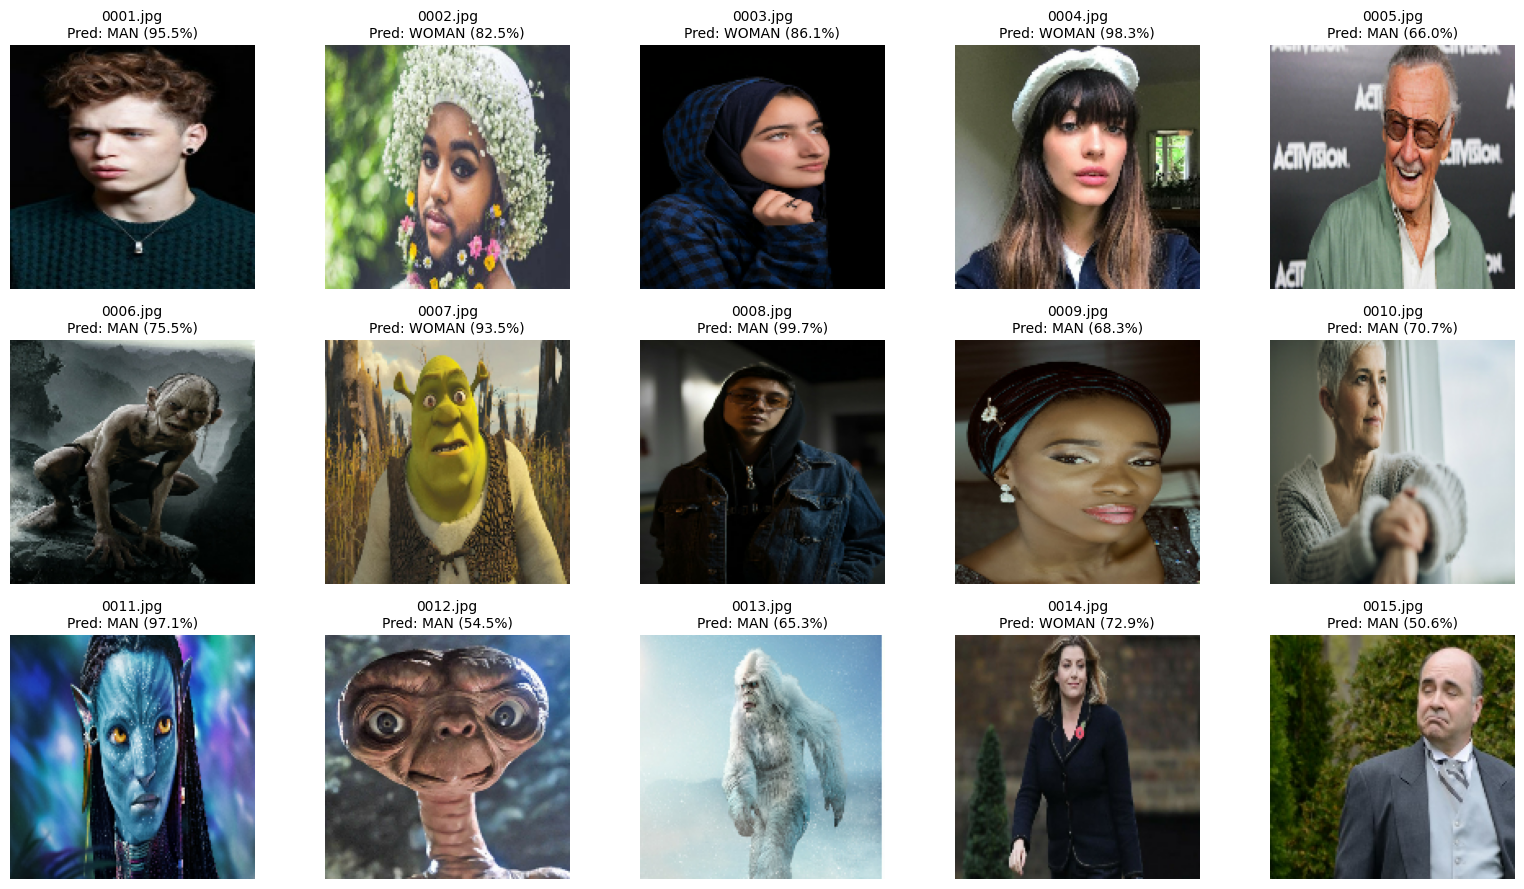

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 1. Get predictions and file paths
predictions = model.predict(predict_ds)
file_paths = predict_ds.file_paths

# 2. Extract image tensors directly from the dataset
images_list = []
for batch_images in predict_ds:
    images_list.extend(batch_images.numpy())

# 3. Setup Grid Plot
num_images = len(file_paths)
cols = 5
rows = (num_images + cols - 1) // cols

plt.figure(figsize=(16, 3 * rows))

for i in range(num_images):
    fname = Path(file_paths[i]).name
    prob = predictions[i][0]

    # Class mapping: > 0.5 is Class 1 (woman), <= 0.5 is Class 0 (man)
    label = class_names[1] if prob > 0.5 else class_names[0]
    confidence = prob if prob > 0.5 else (1 - prob)

    # Plot image
    ax = plt.subplot(rows, cols, i + 1)

    # Convert pixel values to uint8 if necessary for plotting
    img_to_show = images_list[i].astype("uint8")
    plt.imshow(img_to_show)

    # Add title with filename, predicted class, and confidence percentage
    plt.title(f"{fname}\nPred: {label.upper()} ({confidence * 100:.1f}%)", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Plot Accuracy and Loss

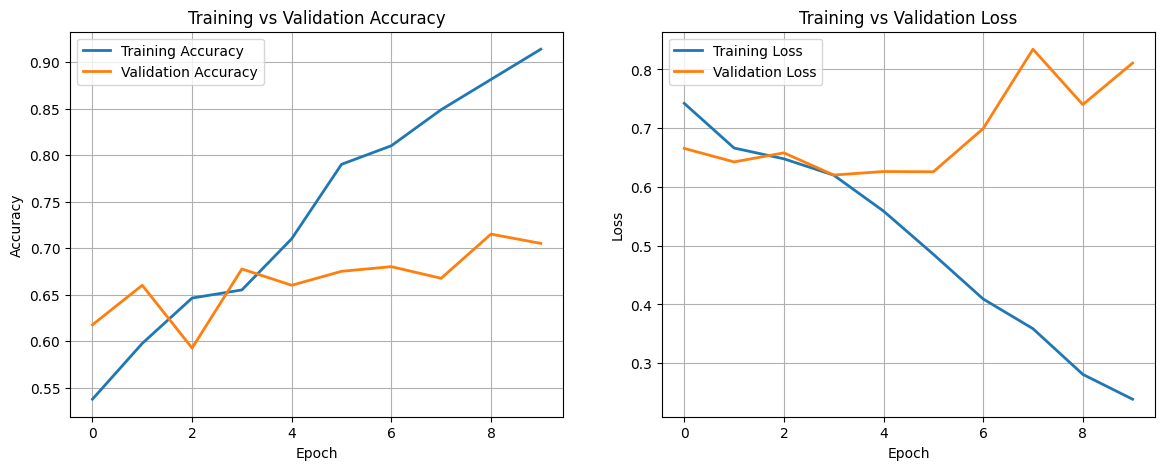

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# 1. Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

# 2. Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

## Generate Predictions for the Test Dataset

The predictions are used to create a confusion matrix and classification report.

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_prob = []

# Iterate through batches in test_ds
for images, labels in test_ds:
    probabilities = model.predict(images, verbose=0).ravel()
    y_prob.extend(probabilities)
    y_true.extend(labels.numpy().ravel())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

# Classify as 1 (woman) if probability >= 0.5, else 0 (man)
y_pred = (y_prob >= 0.5).astype(int)

print(f"Number of test images processed: {len(y_true)}\n")

# Detailed Evaluation Metrics
print("--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_true, y_pred))

Number of test images processed: 400

--- Classification Report ---
              precision    recall  f1-score   support

         man       0.70      0.66      0.68       200
       woman       0.68      0.72      0.70       200

    accuracy                           0.69       400
   macro avg       0.69      0.69      0.69       400
weighted avg       0.69      0.69      0.69       400

--- Confusion Matrix ---
[[131  69]
 [ 55 145]]
